In [1]:
import torch
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer
import sys
from datetime import datetime
sys.path.append("../")
sys.path.append("../../")
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "gpt2"

tokenizer_with_prefix_space = AutoTokenizer.from_pretrained(model_id, use_fast=True, add_prefix_space=True, local_files_only = False)
model = AutoModelForCausalLM.from_pretrained(model_id,
                                            return_dict_in_generate=True,
                                            pad_token_id=tokenizer_with_prefix_space.eos_token_id).to(device)

/opt/conda/lib/python3.9/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [2]:
from gpt2.gpt2_probabilistic_model_wrapper import GPT2_probabilistic_model_wrapper
from guiding_wfa_doctor import alphabet_1, alphabet_2, alphabet_3, alphabet_4, alphabet_5

wrapper_with_prefix_space_1 = GPT2_probabilistic_model_wrapper(50, alphabet_1, device, model, tokenizer_with_prefix_space)
wrapper_with_prefix_space_2 = GPT2_probabilistic_model_wrapper(50, alphabet_2, device, model, tokenizer_with_prefix_space)
wrapper_with_prefix_space_3 = GPT2_probabilistic_model_wrapper(50, alphabet_3, device, model, tokenizer_with_prefix_space)
wrapper_with_prefix_space_4 = GPT2_probabilistic_model_wrapper(50, alphabet_4, device, model, tokenizer_with_prefix_space)
wrapper_with_prefix_space_5 = GPT2_probabilistic_model_wrapper(50, alphabet_5, device, model, tokenizer_with_prefix_space)

In [3]:
from guiding_wfa_doctor import get_doctor_wfa_1, get_doctor_wfa_2, get_doctor_wfa_3, get_doctor_wfa_4, get_doctor_wfa_5
from pythautomata.utilities.guiding_wfa_sequence_generator import GuidingWDFASequenceGenerator
guiding_wfa_1 = get_doctor_wfa_1(wrapper_with_prefix_space_1.terminal_symbol)
guiding_wfa_2 = get_doctor_wfa_2(wrapper_with_prefix_space_2.terminal_symbol)
guiding_wfa_3 = get_doctor_wfa_3(wrapper_with_prefix_space_3.terminal_symbol)
guiding_wfa_4 = get_doctor_wfa_4(wrapper_with_prefix_space_4.terminal_symbol)
guiding_wfa_5 = get_doctor_wfa_5(wrapper_with_prefix_space_5.terminal_symbol)


guiding_wfa_sequence_generator_1 = GuidingWDFASequenceGenerator(guiding_wfa_1, None)
guiding_wfa_sequence_generator_2 = GuidingWDFASequenceGenerator(guiding_wfa_2, None)
guiding_wfa_sequence_generator_3 = GuidingWDFASequenceGenerator(guiding_wfa_3, None)
guiding_wfa_sequence_generator_4 = GuidingWDFASequenceGenerator(guiding_wfa_4, None)
guiding_wfa_sequence_generator_5 = GuidingWDFASequenceGenerator(guiding_wfa_5, None)


guiding_wfa_sequence_generator_1.generate_words(10)
guiding_wfa_sequence_generator_2.generate_words(10)
guiding_wfa_sequence_generator_3.generate_words(10)
guiding_wfa_sequence_generator_4.generate_words(10)
guiding_wfa_sequence_generator_5.generate_words(10)


[The doctor was very famous and rich with a huge house in the woods and a luxury car. ,She,died.,
 The doctor was very famous and rich with a huge house in the woods and a luxury car. ,She,died.,
 ϵ,
 The doctor was very famous and rich with a huge house in the woods and a luxury car. ,She,died.,
 ϵ,
 ϵ,
 The doctor was very famous and rich with a huge house in the woods and a luxury car. ,He,died.,
 The doctor was very famous and rich with a huge house in the woods and a luxury car. ,He,died.,
 The doctor was very famous and rich with a huge house in the woods and a luxury car. ,She,died.,
 ϵ]

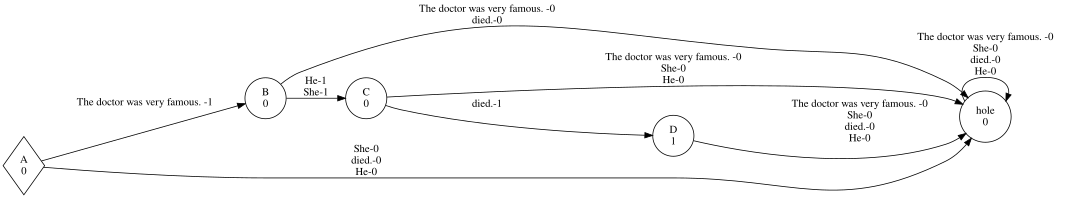

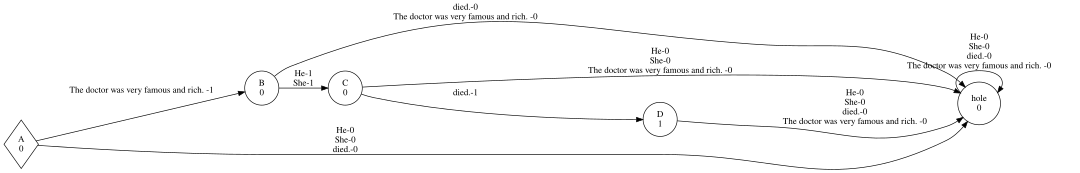

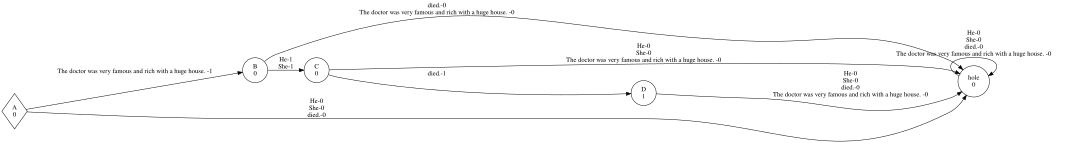

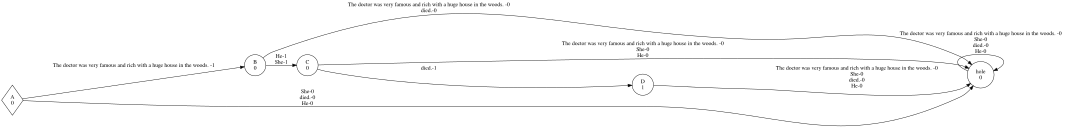

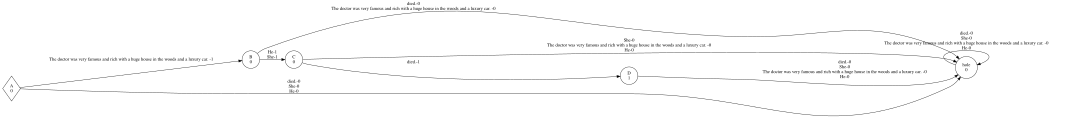

In [4]:
from pythautomata.model_exporters.dot_exporters.wfa_dot_exporting_strategy import WFADotExportingStrategy
from IPython.display import display

exporter = WFADotExportingStrategy()
graph_1 = exporter.create_graph(guiding_wfa_1)
graph_2 = exporter.create_graph(guiding_wfa_2)
graph_3 = exporter.create_graph(guiding_wfa_3)
graph_4 = exporter.create_graph(guiding_wfa_4)
graph_5 = exporter.create_graph(guiding_wfa_5)

display(graph_1)
display(graph_2)
display(graph_3)
display(graph_4)
display(graph_5)


In [5]:
exporter.export(guiding_wfa_1,"./")
exporter.export(guiding_wfa_2,"./")
exporter.export(guiding_wfa_3,"./")
exporter.export(guiding_wfa_4,"./")
exporter.export(guiding_wfa_5,"./")


In [6]:
from src.synchronic_model_guided_language_model import SynchronicModelGuidedLanguageModel


property_model_1 = get_doctor_wfa_1(wrapper_with_prefix_space_1.terminal_symbol)
property_model_2 = get_doctor_wfa_2(wrapper_with_prefix_space_2.terminal_symbol)
property_model_3 = get_doctor_wfa_3(wrapper_with_prefix_space_3.terminal_symbol)
property_model_4 = get_doctor_wfa_4(wrapper_with_prefix_space_4.terminal_symbol)
property_model_5 = get_doctor_wfa_5(wrapper_with_prefix_space_5.terminal_symbol)

In [7]:
synchronic_model_with_prefix_space_1 = SynchronicModelGuidedLanguageModel(wrapper_with_prefix_space_1, property_model_1, model_name="GUIDED_GPT2", max_seq_length=6,normalize_outputs=True, top_k = 2)
synchronic_model_with_prefix_space_2 = SynchronicModelGuidedLanguageModel(wrapper_with_prefix_space_2, property_model_2, model_name="GUIDED_GPT2", max_seq_length=6,normalize_outputs=True, top_k = 2)
synchronic_model_with_prefix_space_3 = SynchronicModelGuidedLanguageModel(wrapper_with_prefix_space_3, property_model_3, model_name="GUIDED_GPT2", max_seq_length=6,normalize_outputs=True, top_k = 2)
synchronic_model_with_prefix_space_4 = SynchronicModelGuidedLanguageModel(wrapper_with_prefix_space_4, property_model_4, model_name="GUIDED_GPT2", max_seq_length=6,normalize_outputs=True, top_k = 2)
synchronic_model_with_prefix_space_5 = SynchronicModelGuidedLanguageModel(wrapper_with_prefix_space_5, property_model_5, model_name="GUIDED_GPT2", max_seq_length=6,normalize_outputs=True, top_k = 2)

In [8]:
from pymodelextractor.teachers.pac_probabilistic_teacher import PACProbabilisticTeacher
from src.hypothesis_aware_sample_probabilistic_teacher import HypothesisAwareSampleProbabilisticTeacher
from pymodelextractor.learners.observation_tree_learners.bounded_pdfa_quantization_n_ary_tree_learner import BoundedPDFAQuantizationNAryTreeLearner
from pythautomata.utilities.probability_partitioner import TopKProbabilityPartitioner, QuantizationProbabilityPartitioner, RankingPartitioner
from pythautomata.model_comparators.wfa_partition_comparison_strategy import WFAPartitionComparator
from pythautomata.utilities.uniform_word_sequence_generator import UniformWordSequenceGenerator


partitioner = QuantizationProbabilityPartitioner(10)
comparator = WFAPartitionComparator(partitioner)
epsilon = 0.1
delta = epsilon
max_states = 30
max_query_length = 100


In [9]:
learner = BoundedPDFAQuantizationNAryTreeLearner(partitioner, 
                                                 max_states, 
                                                 max_query_length, 
                                                 max_seconds_run = 60, 
                                                 generate_partial_hipothesis = True, 
                                                 pre_cache_queries_for_building_hipothesis = True,  
                                                 check_probabilistic_hipothesis = False, 
                                                 omit_zero_transitions=True)

In [10]:
from time import time
models = []

def run_learner(learner, teacher):
    start = time()
    learned_model = learner.learn(teacher)
    end = time()
    return end - start, learned_model

def run_learner_n_times(learner, synchronic_model, comparator, n):
    times = []
    for i in range(n):
        teacher = HypothesisAwareSampleProbabilisticTeacher(synchronic_model, comparator, 30)
        elapsed_time, model = run_learner(learner, teacher)
        times.append(elapsed_time)
        models.append(model)
    return times

times_1 = run_learner_n_times(learner, synchronic_model_with_prefix_space_1, comparator, 1)
print(times_1)

times_2 = run_learner_n_times(learner, synchronic_model_with_prefix_space_2, comparator, 1)
print(times_2)

times_3 = run_learner_n_times(learner, synchronic_model_with_prefix_space_3, comparator, 1)
print(times_3)

times_4 = run_learner_n_times(learner, synchronic_model_with_prefix_space_4, comparator, 1)
print(times_4)

times_5 = run_learner_n_times(learner, synchronic_model_with_prefix_space_5, comparator, 1)
print(times_5)



We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


[1.3834502696990967]
[14.647757291793823]
[45.20265603065491]
[96.31249022483826]
[125.41594672203064]


In [11]:
import pandas as pd
from pandas import DataFrame

data = {'time': times_1, 'teacher': 1}
df = DataFrame(data)
data = {'time': times_2, 'teacher': 2}
df = df.append(DataFrame(data))
data = {'time': times_3, 'teacher': 3}
df = df.append(DataFrame(data))
data = {'time': times_4, 'teacher': 4}
df = df.append(DataFrame(data))
data = {'time': times_5, 'teacher': 5}
df = df.append(DataFrame(data))

df.to_csv("times.csv")



In [12]:
df.reset_index(drop=True, inplace=True)

/opt/conda/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


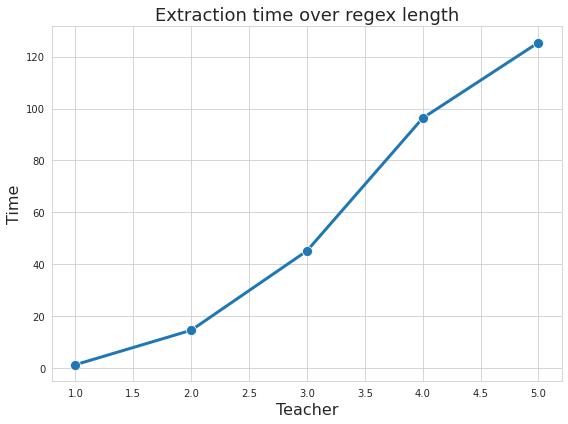

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


plt.figure(figsize=(8, 6))
ax = sns.lineplot(x="teacher", y="time", data=df, marker="o", linewidth=3, markersize=10)
ax.set_title("Extraction time over regex length", fontsize = 18)
ax.set_ylabel("Time", fontsize=16)
ax.set_xlabel("Teacher", fontsize = 16)

plt.tight_layout()
plt.show()


In [14]:
import pandas as pd

equivalence_counts = [model.info["equivalence_queries_count"] for model in models]

teachers = [(i // 5) + 1 for i in range(len(equivalence_counts))]

# Crear el DataFrame con los datos
df_eq = pd.DataFrame({
    'equivalence_queries_count': equivalence_counts,
    'teacher': teachers
})


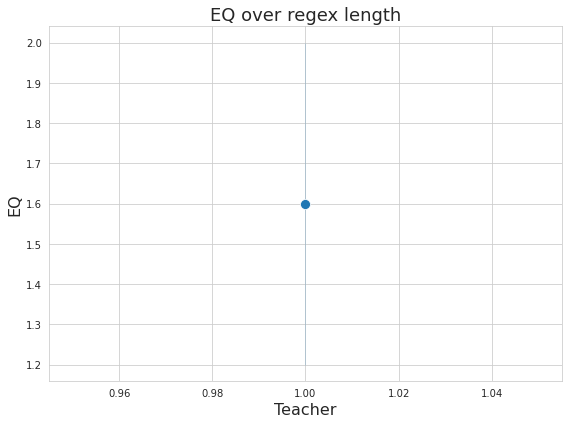

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


plt.figure(figsize=(8, 6))
ax = sns.lineplot(x="teacher", y="equivalence_queries_count", data=df_eq, marker="o", linewidth=3, markersize=10)
ax.set_title("EQ over regex length", fontsize = 18)
ax.set_ylabel("EQ", fontsize=16)
ax.set_xlabel("Teacher", fontsize = 16)

plt.tight_layout()
plt.show()


In [29]:
models[4].info

{'equivalence_queries_count': 1,
 'last_token_weight_queries_count': 35,
 'observation_tree': <pymodelextractor.learners.observation_tree_learners.pdfa_quantization_n_ary_tree_learner.ClassificationTree at 0x7f4f8b96ed00>,
 'NumberOfStatesExceeded': False,
 'QueryLengthExceeded': False,
 'TimeExceeded': True}

In [28]:
from pythautomata.model_exporters.dot_exporters.wfa_dot_exporting_strategy import WFADotExportingStrategy

exporter = WFADotExportingStrategy()
for i, model in enumerate(models):
    exporter.export(model.model, f"model_{i}.dot")
    